#TP5 : text

##Installations

In [ ]:
!pip -q install gensim==4.3.2 sentence-transformers==3.0.1 nltk==3.9.1 matplotlib==3.9.0

In [ ]:
!pip install --upgrade --quiet "numpy<2.0" scikit-learn==1.4.2

In [ ]:
!pip install --quiet "scipy<1.12" gensim==4.3.2

##Données : créer 6 petits documents en français

In [ ]:
# Mini corpus (5–6 documents)
docs = [
    "L’intelligence artificielle transforme de nombreux secteurs, de la santé à la finance.",
    "Les modèles de langage apprennent des textes massifs pour prédire les mots suivants.",
    "Le prétraitement inclut la mise en minuscules, le nettoyage et la suppression des stopwords.",
    "La vectorisation Bag of Words compte les occurrences, tandis que TF-IDF pondère par la rareté.",
    "Word2Vec apprend des représentations continues des mots à partir du contexte.",
    "Les transformers modernes comme MiniLM créent des embeddings de phrases efficaces."
]
len(docs), docs[:2]

(6,
 ['L’intelligence artificielle transforme de nombreux secteurs, de la santé à la finance.',
  'Les modèles de langage apprennent des textes massifs pour prédire les mots suivants.'])

## Préprocessing (lowercase, nettoyage, stopwords NLTK FR)

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

# Téléchargement stopwords FR (la 1ère exécution peut afficher un message de téléchargement)
nltk.download('stopwords')

# Stopwords français
stop_fr = set(stopwords.words('french'))

def simple_tokenize(text):
    # minuscules
    text = text.lower()
    # garder lettres/accents/chiffres + espaces ; remplacer le reste par espace
    text = re.sub(r"[^a-zàâäæçéèêëîïôœùûüÿ0-9\s'-]", " ", text)
    # normaliser espaces
    text = re.sub(r"\s+", " ", text).strip()
    # tokeniser naïvement par espace
    tokens = text.split()
    # retirer stopwords et tokens d'une longueur < 2 (optionnel)
    tokens = [t for t in tokens if t not in stop_fr and len(t) > 1]
    return tokens

tokenized_docs = [simple_tokenize(t) for t in docs]
cleaned_docs = [" ".join(toks) for toks in tokenized_docs]

print("Exemple tokens doc0:", tokenized_docs[0][:15])
print("Doc0 nettoyé:", cleaned_docs[0])


Exemple tokens doc0: ['intelligence', 'artificielle', 'transforme', 'nombreux', 'secteurs', 'santé', 'finance']
Doc0 nettoyé: intelligence artificielle transforme nombreux secteurs santé finance


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


##Matrice Bag of Words (CountVectorizer)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# On utilise les docs nettoyés ; (on pourrait aussi laisser le tokeniseur custom)
cv = CountVectorizer()
X_bow = cv.fit_transform(cleaned_docs)

print("BoW shape:", X_bow.shape)  # (nb_docs, vocab_size)
print("Extrait BoW (dense) pour vérif):")
print(X_bow.toarray())


BoW shape: (6, 47)
Extrait BoW (dense) pour vérif):
[[0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1
  0 0 0 0 0 0 1 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0
  0 1 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0
  1 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0
  0 0 0 1 0 1 0 0 1 0 1]
 [1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0
  0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 1 0 0 0]]


## Matrice TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(cleaned_docs)

print("TF-IDF shape:", X_tfidf.shape)
print("Extrait TF-IDF (dense) pour vérif):")
print(X_tfidf.toarray().round(3))


TF-IDF shape: (6, 47)
Extrait TF-IDF (dense) pour vérif):
[[0.    0.    0.378 0.    0.    0.    0.    0.    0.    0.    0.    0.378
  0.    0.    0.378 0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.378 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.378 0.378
  0.    0.    0.    0.    0.    0.    0.378 0.    0.    0.    0.   ]
 [0.    0.361 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.361 0.361 0.    0.    0.    0.    0.361 0.296 0.
  0.    0.    0.    0.    0.    0.    0.361 0.    0.    0.    0.    0.
  0.    0.361 0.    0.    0.361 0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.378 0.    0.    0.    0.    0.378 0.378 0.    0.    0.    0.378
  0.    0.    0.    0.    0.    0.    0.    0.378 0.    0.    0.    0.
  0.378 0.    0.378 0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.302 0.    0.302 0.    0.    0.    0.    0.    0.
  0.302 0.    0.

##Afficher le vocabulaire extrait

In [ ]:
# Vocabulaire depuis CountVectorizer (même principe avec tfidf.get_feature_names_out())
vocab = cv.get_feature_names_out()
print("Taille du vocabulaire:", len(vocab))
print("Vocabulaire (trié):")
print(sorted(vocab))


Taille du vocabulaire: 47
Vocabulaire (trié):
['apprend', 'apprennent', 'artificielle', 'bag', 'comme', 'compte', 'contexte', 'continues', 'créent', 'efficaces', 'embeddings', 'finance', 'idf', 'inclut', 'intelligence', 'langage', 'massifs', 'minilm', 'minuscules', 'mise', 'modernes', 'modèles', 'mots', 'nettoyage', 'nombreux', 'occurrences', 'of', 'partir', 'phrases', 'pondère', 'prédire', 'prétraitement', 'rareté', 'représentations', 'santé', 'secteurs', 'stopwords', 'suivants', 'suppression', 'tandis', 'textes', 'tf', 'transforme', 'transformers', 'vectorisation', 'word2vec', 'words']


## Word2Vec sur les mots + réduction PCA 3D + plot

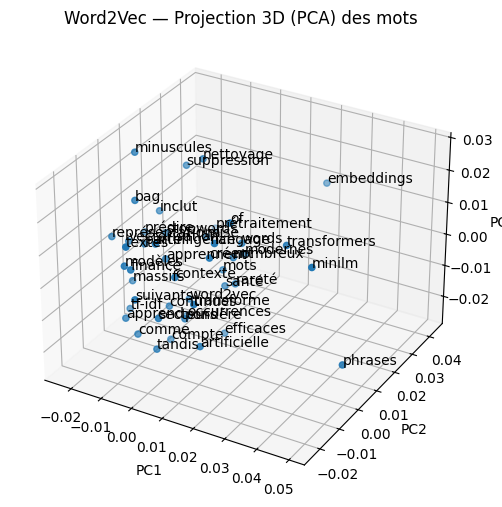

In [ ]:
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (nécessaire pour le 3D)

# Entraîner Word2Vec (petit corpus => paramètres modestes)
w2v = Word2Vec(
    sentences=tokenized_docs,
    vector_size=100,
    window=5,
    min_count=1,
    workers=2,
    sg=1,         # skip-gram (souvent mieux sur petits corpus)
    epochs=200,
    seed=42
)

# Récupérer les vecteurs de tous les mots du vocabulaire Word2Vec
words = list(w2v.wv.index_to_key)
W = np.vstack([w2v.wv[w] for w in words])

# Réduction à 3 composantes
pca3 = PCA(n_components=3, random_state=42)
W3 = pca3.fit_transform(W)

# Plot 3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(W3[:,0], W3[:,1], W3[:,2])

# Ajouter quelques labels (tous les labels sur un petit corpus reste lisible)
for i, w in enumerate(words):
    ax.text(W3[i,0], W3[i,1], W3[i,2], w)

ax.set_title("Word2Vec — Projection 3D (PCA) des mots")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()


##MiniLM (sentence-transformers) pour les phrases + PCA 3D + plot

/usr/local/lib/python3.12/dist-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

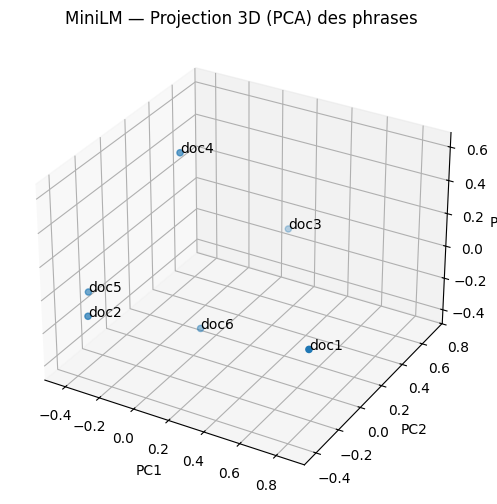

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Modèle MiniLM multilingue (bon pour le français)
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
st_model = SentenceTransformer(model_name)

# Embeddings de phrases sur les documents *originaux* (mieux que les nettoyés)
sent_emb = st_model.encode(docs, convert_to_numpy=True, normalize_embeddings=True)

# Réduction à 3D
pca3 = PCA(n_components=3, random_state=42)
S3 = pca3.fit_transform(sent_emb)

# Plot 3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(S3[:,0], S3[:,1], S3[:,2])

# Ajouter les étiquettes courtes (id doc)
for i, s in enumerate(docs):
    ax.text(S3[i,0], S3[i,1], S3[i,2], f"doc{i+1}")

ax.set_title("MiniLM — Projection 3D (PCA) des phrases")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()


# TP3 : Image

## Import et chargement du dataset

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image

import kagglehub
path = kagglehub.dataset_download("msarmi9/food101tiny")

# Exemple: on prend la classe "apple_pie"
data_path = os.path.join(path, 'data', 'food-101-tiny','train', 'apple_pie')

image_files = os.listdir(data_path)
print(f'Number of images: {len(image_files)}')
print("first 5 image files:", image_files[:5])


Using Colab cache for faster access to the 'food101tiny' dataset.
Number of images: 150
first 5 image files: ['1159801.jpg', '1077964.jpg', '1305678.jpg', '1725573.jpg', '1322211.jpg']


## Charger une image et afficher sa dimension

In [ ]:
# Charger une image au hasard
img_path = os.path.join(data_path, random.choice(image_files))
img = Image.open(img_path)

print("Image path:", img_path)
print("Image size (H, W):", img.size)  # format (width, height)


Image path: /kaggle/input/food101tiny/data/food-101-tiny/train/apple_pie/1239205.jpg
Image size (H, W): (512, 512)


## Visualiser quelques images avec matplotlib

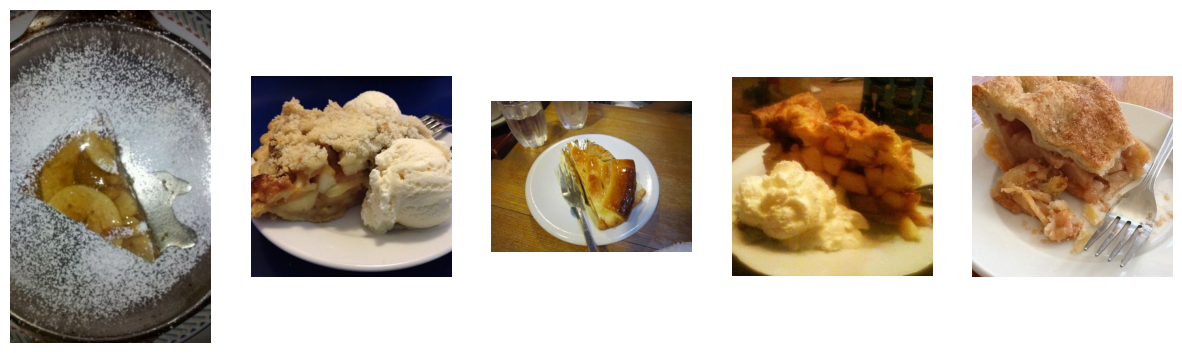

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for ax in axes:
    img_path = os.path.join(data_path, random.choice(image_files))
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.show()


## Normaliser les pixels entre 0 et 1

In [ ]:
# Charger une image en tableau numpy
img_array = np.array(img)
print("Original dtype:", img_array.dtype)

# Normalisation
img_norm = img_array / 255.0
print("Normalized dtype:", img_norm.dtype)
print("Pixel range:", img_norm.min(), "to", img_norm.max())


Original dtype: uint8
Normalized dtype: float64
Pixel range: 0.0 to 1.0


## Calculer moyenne et écart-type

In [ ]:
mean = img_norm.mean()
std = img_norm.std()

print("Mean pixel value:", mean)
print("Std pixel value:", std)


Mean pixel value: 0.5827337576672923
Std pixel value: 0.24313364389958333


# TP6 : Video


## Import & affichage d'une vidéo

In [ ]:
import os
import kagglehub

# Télécharger le dataset
path = kagglehub.dataset_download("mistag/short-videos")
print("Path to dataset files:", path)

# Chemin vers les vidéos
video_dir = os.path.join(path, "animals")
exts = (".mp4", ".avi", ".mov", ".mkv")

# Lister les vidéos disponibles
videos = [os.path.join(video_dir, f) for f in os.listdir(video_dir) if f.lower().endswith(exts)]
assert videos, "Aucune vidéo trouvée dans le dossier"

print("Vidéos trouvées:", [os.path.basename(v) for v in videos])


Using Colab cache for faster access to the 'short-videos' dataset.
Path to dataset files: /kaggle/input/short-videos
Vidéos trouvées: ['elefant_1280p.mp4', 'giraffes_1280p.mp4']


## Choisir une vidéo au hasard et l’afficher

In [ ]:
import random
from IPython.display import Video, display

# Choisir une vidéo au hasard
vid_path = random.choice(videos)
print("Selected:", os.path.basename(vid_path))

# Afficher la vidéo dans le notebook
display(Video(vid_path, embed=True, width=480))


## Lire les métadonnées (FPS, nb frames, durée)

In [ ]:
import cv2

cap = cv2.VideoCapture(vid_path)
fps = cap.get(cv2.CAP_PROP_FPS)
nframes = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = nframes / fps if fps else None

print(f"FPS: {fps:.2f} | Frames: {nframes} | Durée (s): {duration:.2f}")
cap.release()

FPS: 29.97 | Frames: 1064 | Durée (s): 35.50


## Extraire 3 frames par seconde et les afficher

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(vid_path)

frames = []
target_fps = 3   # nombre de frames à extraire par seconde

# liste des index de frames qu’on veut garder
frame_indices = np.arange(0, nframes, int(round(fps / target_fps)))

frame_idx = 0
grab_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx in frame_indices:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)

    frame_idx += 1

cap.release()

print(f"{len(frames)} frames extraites.")

# Affichage
cols = 3
rows = (len(frames) + cols - 1) // cols
plt.figure(figsize=(15, rows * 3))

for i, f in enumerate(frames):
    plt.subplot(rows, cols, i+1)
    plt.imshow(f)
    plt.axis("off")
    plt.title(f"Frame {i}")

plt.tight_layout()
plt.show()

## Sauvegarder les frames dans un dossier

In [ ]:
from pathlib import Path

# Créer un dossier de sortie
out_dir = Path("frames_output")
out_dir.mkdir(exist_ok=True)

# Sauvegarder toutes les frames
for i, f in enumerate(frames):
    out_path = out_dir / f"frame_{i:04d}.jpg"
    cv2.imwrite(str(out_path), cv2.cvtColor(f, cv2.COLOR_RGB2BGR))

print(f"Frames sauvegardées dans: {out_dir.resolve()}")


Frames sauvegardées dans: /content/frames_output


#TP2 : audio


## Install dependencies and download dataset

In [ ]:
!pip install -q kagglehub librosa matplotlib

import kagglehub

# Download dataset
path = kagglehub.dataset_download("ouaraskhelilrafik/tp-02-audio")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'tp-02-audio' dataset.
Dataset downloaded to: /kaggle/input/tp-02-audio


## Import libraries and pick a random audio file

In [ ]:
import os
import random
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Collect all .wav and .ogg files
audio_files = []
for root, dirs, files in os.walk(path):
    for f in files:
        if f.lower().endswith((".wav", ".ogg")):
            audio_files.append(os.path.join(root, f))

# Choose a random file
file_path = random.choice(audio_files)
print("Randomly selected file:", file_path)

# Load the audio
signal, sr = librosa.load(file_path, sr=None)  # sr=None keeps original sampling rate

print("Sampling rate:", sr)
print("Signal shape:", signal.shape)
print("Duration (seconds):", librosa.get_duration(y=signal, sr=sr))


Randomly selected file: /kaggle/input/tp-02-audio/Data/Data/105 - Frog/2-52789-A.ogg
Sampling rate: 44100
Signal shape: (221376,)
Duration (seconds): 5.019863945578232


## Plot waveform

In [ ]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(signal, sr=sr)
plt.title(f"Waveform: {os.path.basename(file_path)}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()


## Compute and display spectrogram

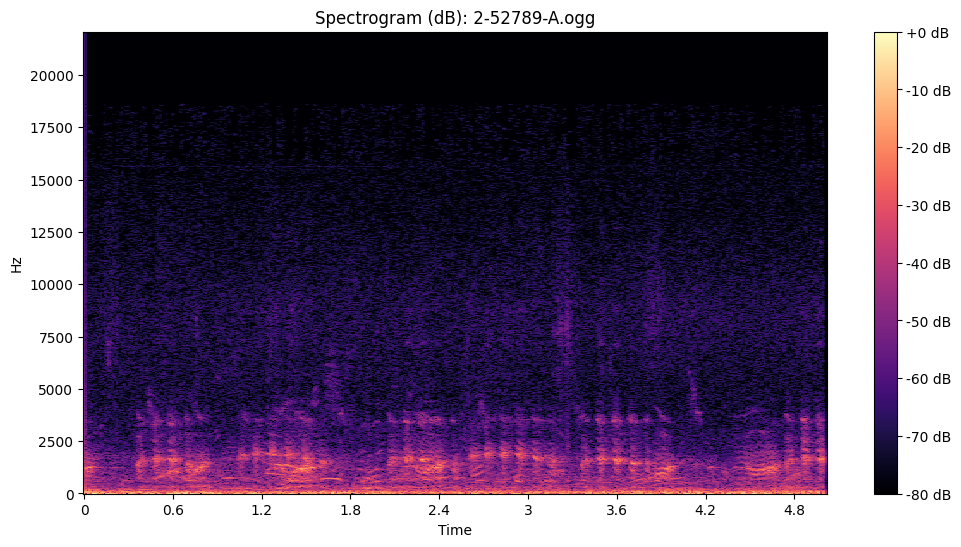

In [ ]:
# Short-Time Fourier Transform (STFT)
stft = librosa.stft(signal)
spectrogram = np.abs(stft)

# Convert to decibels
spectrogram_db = librosa.amplitude_to_db(spectrogram, ref=np.max)

plt.figure(figsize=(12, 6))
librosa.display.specshow(spectrogram_db, sr=sr, x_axis="time", y_axis="hz", cmap="magma")
plt.colorbar(format="%+2.0f dB")
plt.title(f"Spectrogram (dB): {os.path.basename(file_path)}")
plt.show()


## Play the audio

In [ ]:
from IPython.display import Audio

Audio(data=signal, rate=sr)

# TP1 : Time Series

In [ ]:
# Download dataset
path = kagglehub.dataset_download("erogluegemen/airline-passengers")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'airline-passengers' dataset.
Dataset downloaded to: /kaggle/input/airline-passengers


In [ ]:
import pandas as pd
import os

# Cherche le fichier CSV dans le dossier téléchargé
files = os.listdir(path)
print("Fichiers disponibles :", files)

# Supposons que le fichier s'appelle "AirPassengers.csv"
csv_path = os.path.join(path, "airline-passengers.csv")

# Charger le dataset
data = pd.read_csv(csv_path)

# Afficher les 5 premières lignes
print(data.head())


Fichiers disponibles : ['airline-passengers.csv']
     month  total_passengers
0  1949-01               112
1  1949-02               118
2  1949-03               132
3  1949-04               129
4  1949-05               121


In [ ]:
data['month'] = pd.to_datetime(data['month'])
data.set_index('month', inplace=True)

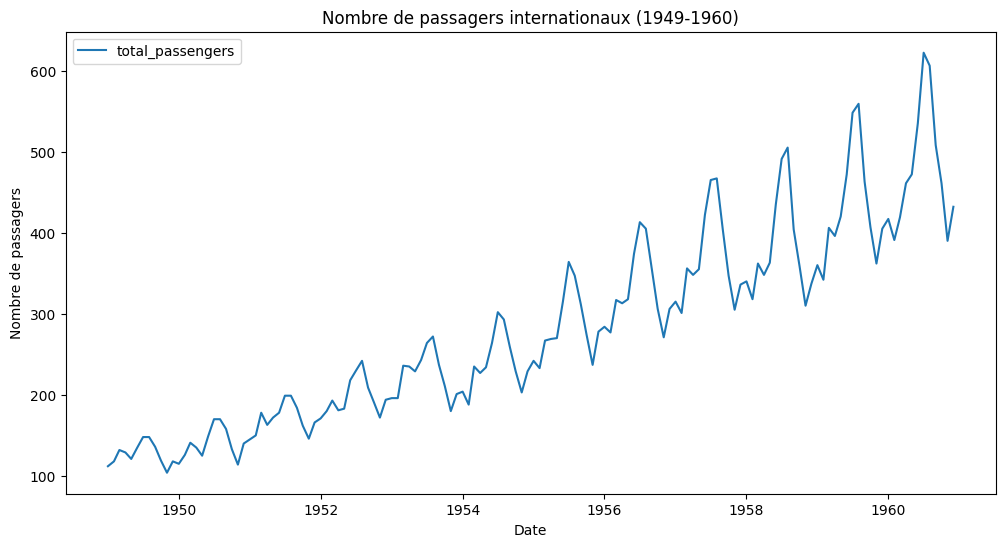

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(data, label="total_passengers")
plt.title("Nombre de passagers internationaux (1949-1960)")
plt.xlabel("Date")
plt.ylabel("Nombre de passagers")
plt.legend()
plt.show()


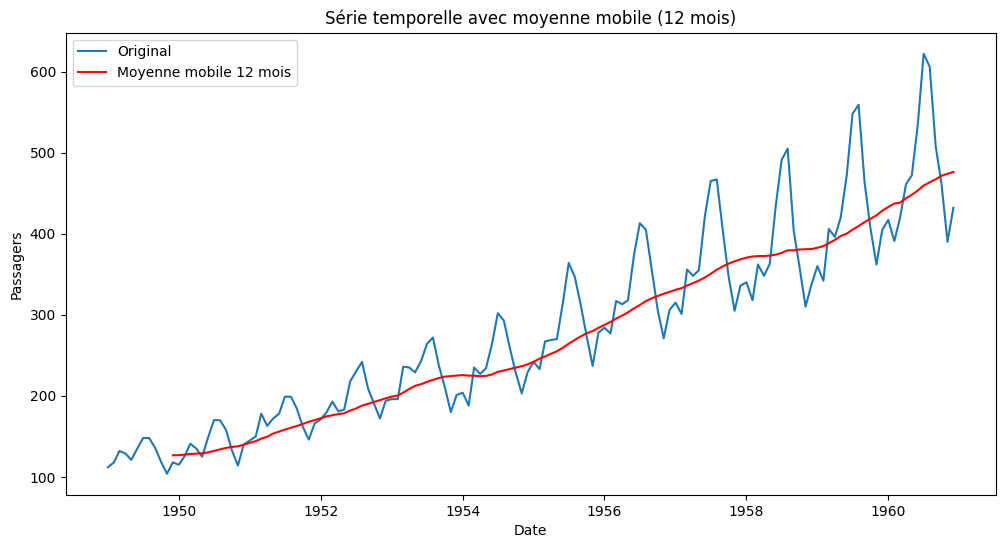

In [ ]:
data['MA12'] = data['total_passengers'].rolling(window=12).mean()

plt.figure(figsize=(12,6))
plt.plot(data['total_passengers'], label="Original")
plt.plot(data['MA12'], label="Moyenne mobile 12 mois", color='red')
plt.title("Série temporelle avec moyenne mobile (12 mois)")
plt.xlabel("Date")
plt.ylabel("Passagers")
plt.legend()
plt.show()

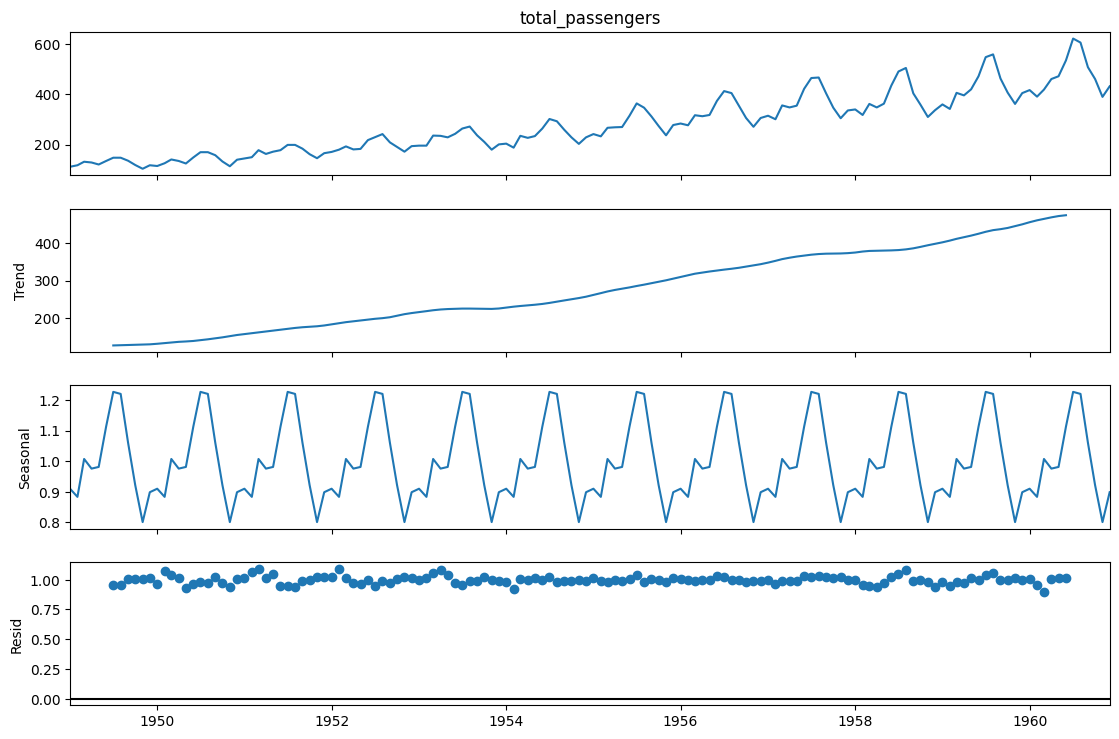

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(data['total_passengers'], model='multiplicative', period=12)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

# TP4: Graphs

In [ ]:
!pip install networkx ipycytoscape

## Cell 2: imports

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from ipycytoscape import CytoscapeWidget
import urllib.request
import gzip
import shutil


## download and load the Facebook graph (edge list)

In [ ]:
url = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
local_gz = "facebook_combined.txt.gz"
local_txt = "facebook_combined.txt"

# Download
urllib.request.urlretrieve(url, local_gz)

# Unzip
with gzip.open(local_gz, 'rb') as f_in:
    with open(local_txt, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

# Load into NetworkX
G = nx.read_edgelist(local_txt, nodetype=int)
G = nx.Graph(G)  # ensure simple graph


## number of nodes / edges

In [ ]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())


Number of nodes: 4039
Number of edges: 88234


## plot (matplotlib)

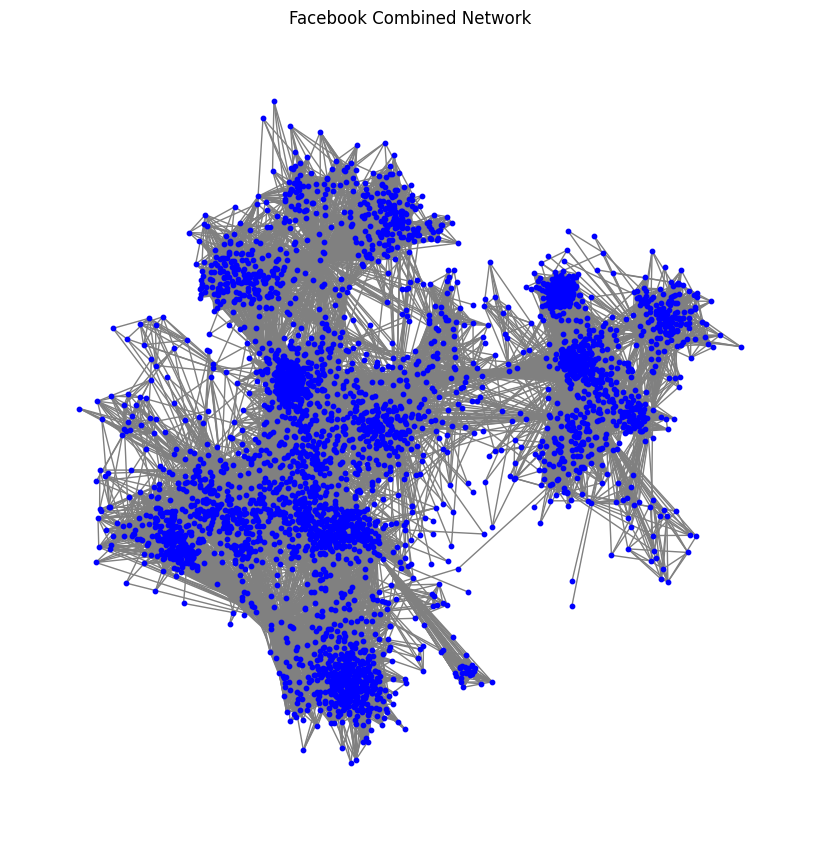

In [ ]:
plt.figure(figsize=(8,8))
nx.draw(G, node_size=10, node_color="blue", edge_color="gray", with_labels=False)
plt.title("Facebook Combined Network")
plt.show()


## compute degree of each node

In [ ]:
degrees = dict(G.degree())
# Print a few examples
print("Degrees (sample):", list(degrees.items())[:10])


Degrees (sample): [(0, 347), (1, 17), (2, 10), (3, 17), (4, 10), (5, 13), (6, 6), (7, 20), (8, 8), (9, 57)]


## histogram of degree distribution

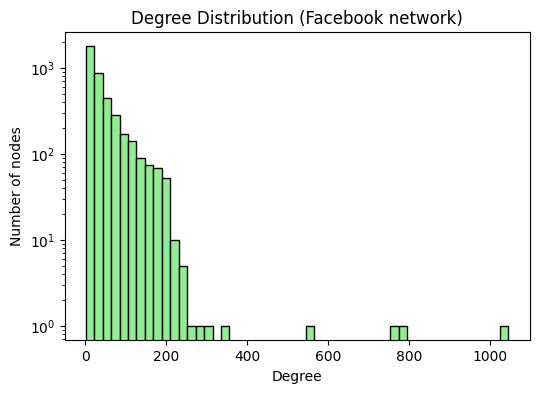

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(list(degrees.values()), bins=50, color="lightgreen", edgecolor="black")
plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.title("Degree Distribution (Facebook network)")
plt.yscale('log')
plt.show()


## interactive visualization via ipycytoscape

In [ ]:
cyto = CytoscapeWidget()
cyto.graph.add_graph_from_networkx(G)
cyto.set_style([
    {
        'selector': 'node',
        'style': {
            'label': 'data(id)',
            'background-color': 'skyblue',
            'width': '20px',
            'height': '20px'
        }
    },
    {
        'selector': 'edge',
        'style': {
            'line-color': 'gray'
        }
    }
])
cyto


CytoscapeWidget(cytoscape_layout={'name': 'cola'}, cytoscape_style=[{'selector': 'node', 'style': {'label': 'd…